In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# === 信号生成関数 ===
def generate_noisy_signals(freq=10, phase_diff=np.pi/4, fs=250, duration=4.0, noise_level=0.3):
    """EEG風のノイズ付き正弦波を生成"""
    t = np.arange(0, duration, 1/fs)
    # 基本波
    x = np.sin(2 * np.pi * freq * t)
    y = np.sin(2 * np.pi * freq * t + phase_diff)
    # 1/fノイズを付加（EEGノイズっぽくする）
    def pink_noise(n):
        uneven = n % 2
        X = np.random.randn(n // 2 + 1 + uneven) + 1j * np.random.randn(n // 2 + 1 + uneven)
        S = np.sqrt(np.arange(len(X)) + 1.)  # 1/fスペクトル
        y = (np.fft.irfft(X / S)).real
        return y[:n]
    noise_x = pink_noise(len(x)) * noise_level
    noise_y = pink_noise(len(y)) * noise_level
    return t, x + noise_x, y + noise_y

# === 位相計算 ===
def compute_phase(x):
    return np.angle(hilbert(x))

# === 各同期指標 ===
def PSI(x, y, N=100):
    phase_x = compute_phase(x)
    phase_y = compute_phase(y)
    delta = phase_x - phase_y
    psi_vals = []
    for i in range(0, len(delta)-N):
        psi_vals.append(np.abs(np.mean(np.exp(1j*delta[i:i+N]))))
    return np.array(psi_vals)

def Imaginary_Coh(x, y):
    X = np.fft.fft(x)
    Y = np.fft.fft(y)
    csd = X * np.conj(Y)
    imag_coh = np.imag(np.mean(csd)) / np.sqrt(np.mean(np.abs(X)**2) * np.mean(np.abs(Y)**2))
    return np.abs(imag_coh)

def PLI(x, y):
    delta = compute_phase(x) - compute_phase(y)
    return np.abs(np.mean(np.sign(np.sin(delta))))

def wPLI(x, y):
    X = np.fft.fft(x)
    Y = np.fft.fft(y)
    imag_part = np.imag(X * np.conj(Y))
    return np.abs(np.sum(np.abs(imag_part) * np.sign(imag_part))) / np.sum(np.abs(imag_part))

def dPSI(x, y):
    phase_x = compute_phase(x)
    phase_y = compute_phase(y)
    delta = np.unwrap(phase_x - phase_y)
    d_delta = np.diff(delta)
    return np.mean(np.abs(d_delta))



PSI(mean): 1.000
Imaginary Coherence: 0.000
PLI: 1.000
wPLI: 0.000
dPSI: 0.003


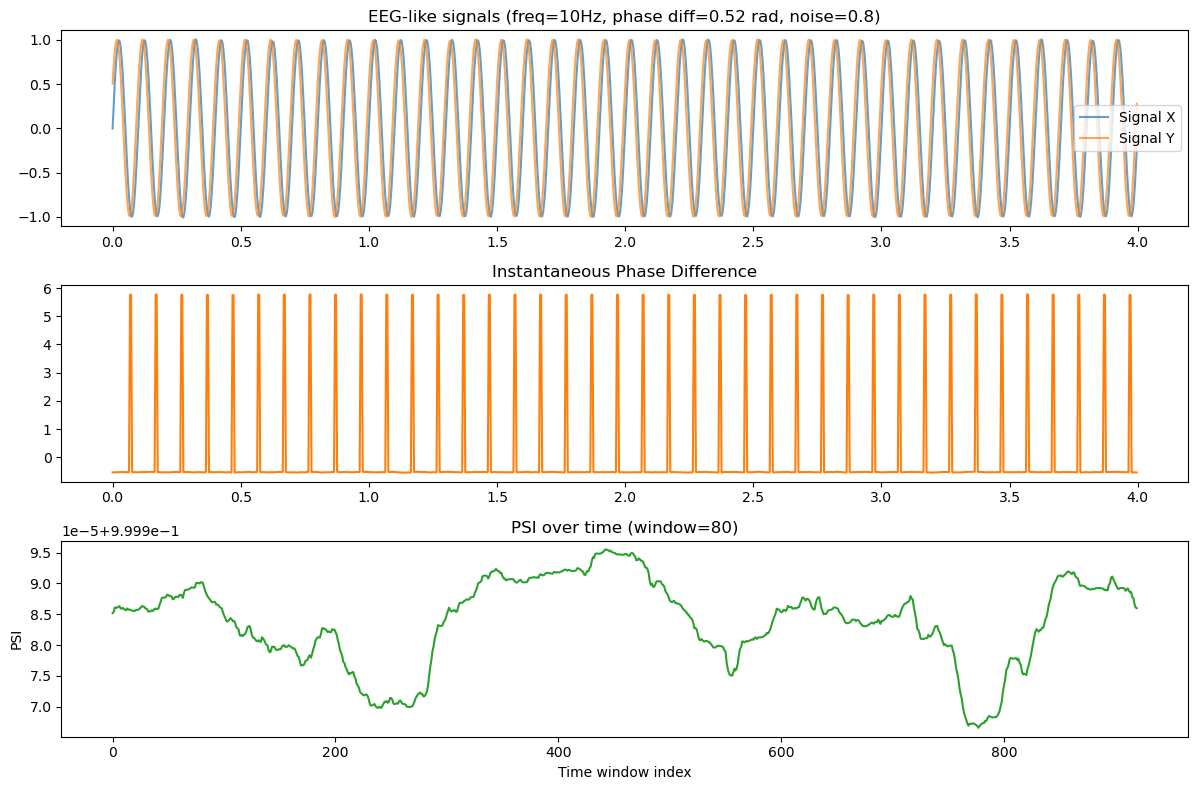

In [9]:
# === パラメータ設定 ===
freq = 10           # 周波数 [Hz]
phase_diff = np.pi/6 # 位相差 [rad]
fs = 250            # サンプリング周波数
duration = 4.0      # 秒
N = 80              # PSI計算の窓幅
noise_level = 0.8   # ノイズレベル（EEG風）

# === 信号生成 ===
t, x, y = generate_noisy_signals(freq, phase_diff, fs, duration, noise_level)

# === 指標計算 ===
psi_vals = PSI(x, y, N)
imag_coh = Imaginary_Coh(x, y)
pli_val = PLI(x, y)
wpli_val = wPLI(x, y)
dpsi_val = dPSI(x, y)

# === 結果出力 ===
print(f"PSI(mean): {np.mean(psi_vals):.3f}")
print(f"Imaginary Coherence: {imag_coh:.3f}")
print(f"PLI: {pli_val:.3f}")
print(f"wPLI: {wpli_val:.3f}")
print(f"dPSI: {dpsi_val:.3f}")

# === 可視化 ===
plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.title(f"EEG-like signals (freq={freq}Hz, phase diff={phase_diff:.2f} rad, noise={noise_level})")
plt.plot(t, x, label='Signal X', alpha=0.7)
plt.plot(t, y, label='Signal Y', alpha=0.7)
plt.legend()

plt.subplot(3,1,2)
plt.title("Instantaneous Phase Difference")
plt.plot(t, compute_phase(x) - compute_phase(y), color='tab:orange')

plt.subplot(3,1,3)
plt.title(f"PSI over time (window={N})")
plt.plot(psi_vals, color='tab:green')
plt.xlabel("Time window index")
plt.ylabel("PSI")
plt.tight_layout()
plt.show()
